In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
import os
import json

# Create kaggle directory
os.makedirs('/root/.kaggle', exist_ok=True)

# Create kaggle.json with your credentials
kaggle_json = {
    "username": "itxminoo",
    "key": "KGAT_4c9b6753aeb313fd7be04409838e5992"
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_json, f)

os.chmod('/root/.kaggle/kaggle.json', 600)
print("Kaggle configured ✅")

Kaggle configured ✅


In [5]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
print("Downloaded ✅")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [01:02<00:00, 39.7MB/s]

Downloaded ✅


In [6]:
import os
if os.path.exists('chest-xray-pneumonia.zip'):
    size = os.path.getsize('chest-xray-pneumonia.zip') / (1024*1024)
    print(f"✅ File exists! Size: {size:.2f} MB")
else:
    print("❌ File not found - download failed")

✅ File exists! Size: 2349.25 MB


In [7]:
import zipfile

print("Extracting... ⏳ This may take 1-2 minutes")
with zipfile.ZipFile('chest-xray-pneumonia.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')
print("Extracted ✅")

# Check structure
import os
for root, dirs, files in os.walk('/content/dataset'):
    level = root.replace('/content/dataset', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2 and files:
        print(f'{indent}  ({len(files)} files)')

Extracting... ⏳ This may take 1-2 minutes
Extracted ✅
dataset/
  chest_xray/
    val/
      PNEUMONIA/
      NORMAL/
    __MACOSX/
      chest_xray/
        val/
          PNEUMONIA/
          NORMAL/
        test/
          PNEUMONIA/
          NORMAL/
        train/
          PNEUMONIA/
          NORMAL/
    test/
      PNEUMONIA/
      NORMAL/
    chest_xray/
      val/
        PNEUMONIA/
        NORMAL/
      test/
        PNEUMONIA/
        NORMAL/
      train/
        PNEUMONIA/
        NORMAL/
    train/
      PNEUMONIA/
      NORMAL/


In [8]:
import os

# The actual data is in this nested path
base_path = '/content/dataset/chest_xray/chest_xray'

train_dir = os.path.join(base_path, 'train')
test_dir = os.path.join(base_path, 'test')
val_dir = os.path.join(base_path, 'val')

# Count images
for split, path in [('Train', train_dir), ('Test', test_dir), ('Val', val_dir)]:
    normal_count = len(os.listdir(os.path.join(path, 'NORMAL')))
    pneumonia_count = len(os.listdir(os.path.join(path, 'PNEUMONIA')))
    print(f"{split}: Normal={normal_count}, Pneumonia={pneumonia_count}")

Train: Normal=1342, Pneumonia=3876
Test: Normal=234, Pneumonia=390
Val: Normal=9, Pneumonia=9


In [9]:
import cv2
import numpy as np

IMG_SIZE = 150
LIMIT_PER_CLASS = 600  # Limit to avoid RAM crash

def load_images(directory, limit=None):
    images = []
    labels = []

    for label, folder in enumerate(['NORMAL', 'PNEUMONIA']):
        folder_path = os.path.join(directory, folder)
        files = os.listdir(folder_path)
        if limit:
            files = files[:limit]

        for i, filename in enumerate(files):
            img_path = os.path.join(folder_path, filename)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                images.append(img)
                labels.append(label)

            if (i+1) % 100 == 0:
                print(f"{folder}: {i+1} images loaded...")

    return np.array(images), np.array(labels)

print("Loading training images... ⏳")
X_train, y_train = load_images(train_dir, limit=LIMIT_PER_CLASS)
print(f"Train shape: {X_train.shape} ✅")

print("\nLoading test images... ⏳")
X_test, y_test = load_images(test_dir, limit=200)
print(f"Test shape: {X_test.shape} ✅")

Loading training images... ⏳
NORMAL: 100 images loaded...
NORMAL: 200 images loaded...
NORMAL: 300 images loaded...
NORMAL: 400 images loaded...
NORMAL: 500 images loaded...
NORMAL: 600 images loaded...
PNEUMONIA: 100 images loaded...
PNEUMONIA: 200 images loaded...
PNEUMONIA: 300 images loaded...
PNEUMONIA: 400 images loaded...
PNEUMONIA: 500 images loaded...
PNEUMONIA: 600 images loaded...
Train shape: (1200, 150, 150, 3) ✅

Loading test images... ⏳
NORMAL: 100 images loaded...
NORMAL: 200 images loaded...
PNEUMONIA: 100 images loaded...
PNEUMONIA: 200 images loaded...
Test shape: (400, 150, 150, 3) ✅


Normal in train: 600
Pneumonia in train: 600


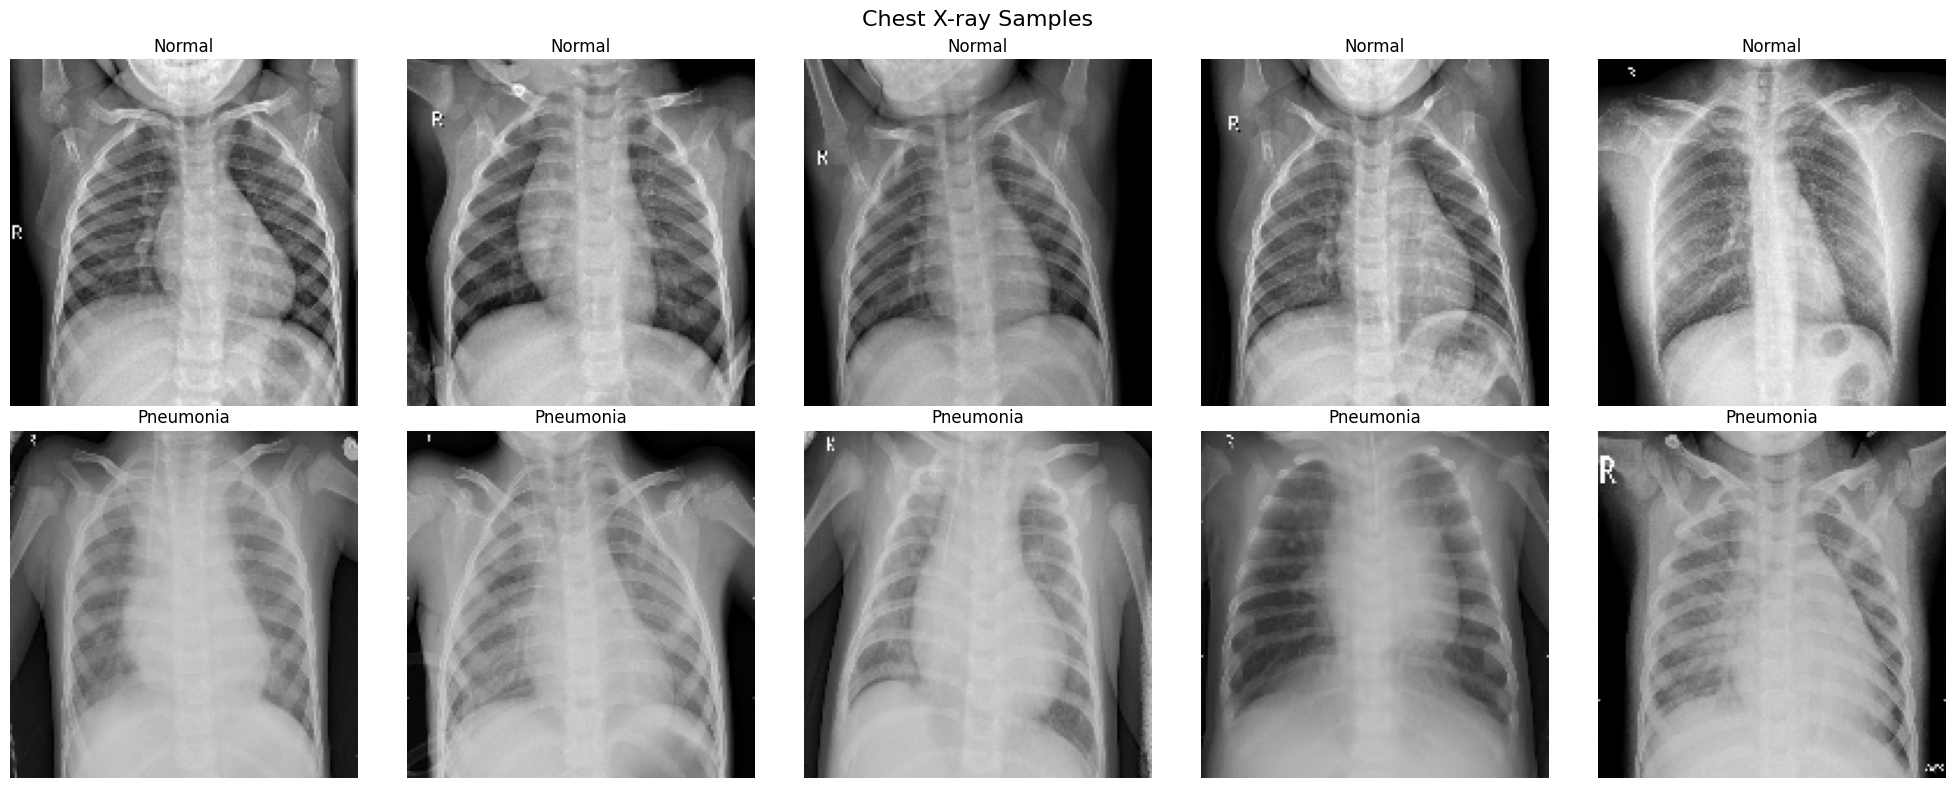

Saved! ✅


In [10]:
# Normalize
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(f"Normal in train: {(y_train==0).sum()}")
print(f"Pneumonia in train: {(y_train==1).sum()}")

# Visualize samples
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i in range(5):
    axes[0, i].imshow(X_train[i])
    axes[0, i].set_title('Normal' if y_train[i]==0 else 'Pneumonia')
    axes[0, i].axis('off')

    idx = len(X_train) - 1 - i
    axes[1, i].imshow(X_train[idx])
    axes[1, i].set_title('Normal' if y_train[idx]==0 else 'Pneumonia')
    axes[1, i].axis('off')

plt.suptitle('Chest X-ray Samples', fontsize=16)
plt.tight_layout()
plt.savefig('pneumonia_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved! ✅")

In [11]:
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam

def build_cnn(input_shape=(150, 150, 3)):
    model = tf.keras.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model = build_cnn()
model.summary()
print("CNN built! ✅")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,519,809 (13.43 MB)

 Trainable params: 3,519,105 (13.42 MB)

 Non-trainable params: 704 (2.75 KB)

CNN built! ✅


In [12]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.2, patience=3, verbose=1)
]

print("Training started... ⏳")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    callbacks=callbacks
)
print("Training complete! ✅")

Training started... ⏳
Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 230ms/step - accuracy: 0.8617 - loss: 0.3892 - val_accuracy: 0.5000 - val_loss: 1.2921 - learning_rate: 1.0000e-04
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9500 - loss: 0.1520 - val_accuracy: 0.5000 - val_loss: 2.4275 - learning_rate: 1.0000e-04
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9600 - loss: 0.1403 - val_accuracy: 0.5000 - val_loss: 3.3673 - learning_rate: 1.0000e-04
Epoch 4/20
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9550 - loss: 0.1152
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9633 - loss: 0.0916 - val_accuracy: 0.5000 - val_loss: 4.0782 - learning_rate: 1.0000e-04
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9725 - loss: 0.0682 - val_accuracy: 0.5000 - val_loss: 4.6753 - learning_rate: 2.0000e-05
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step

In [13]:
print("Test set distribution:")
print(f"Normal: {(y_test==0).sum()}")
print(f"Pneumonia: {(y_test==1).sum()}")

# Check if model predicts only one class
predictions = model.predict(X_test[:20])
print("\nSample predictions:", predictions.flatten()[:10])
print("Actual labels:", y_test[:10])

Test set distribution:
Normal: 200
Pneumonia: 200
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Sample predictions: [0.9162628  0.9187516  0.9179717  0.9158835  0.9170145  0.91977626
 0.91793513 0.9184661  0.9179054  0.91462696]
Actual labels: [0 0 0 0 0 0 0 0 0 0]


In [14]:
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam

# Clear previous model
tf.keras.backend.clear_session()

def build_better_cnn(input_shape=(150, 150, 3)):
    model = tf.keras.Sequential([
        layers.Conv2D(32, (3,3), activation='relu',
                     input_shape=input_shape, padding='same'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model = build_better_cnn()

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()
print("New model built ✅")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

New model built ✅


In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

datagen.fit(X_train)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=8, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.5, patience=4, verbose=1, min_lr=1e-6)
]

print("Training with augmentation... ⏳")
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=25,
    callbacks=callbacks
)
print("Training complete! ✅")

Training with augmentation... ⏳
Epoch 1/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 18s 298ms/step - accuracy: 0.4925 - loss: 0.6968 - val_accuracy: 0.5000 - val_loss: 0.6919 - learning_rate: 0.0010
Epoch 2/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 157ms/step - accuracy: 0.5308 - loss: 0.6906 - val_accuracy: 0.5625 - val_loss: 0.6925 - learning_rate: 0.0010
Epoch 3/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 187ms/step - accuracy: 0.6842 - loss: 0.6654 - val_accuracy: 0.5775 - val_loss: 0.7000 - learning_rate: 0.0010
Epoch 4/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 160ms/step - accuracy: 0.6983 - loss: 0.6285 - val_accuracy: 0.6300 - val_loss: 0.6820 - learning_rate: 0.0010
Epoch 5/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 190ms/step - accuracy: 0.7133 - loss: 0.5942 - val_accuracy: 0.5975 - val_loss: 0.7105 - learning_rate: 0.0010
Epoch 6/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 161ms/step - accuracy: 0.7225 - loss: 0.5752 - val_accuracy: 0.6450 - val_loss: 0.6620 - learning_rate: 0.0010
Epoch 7/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 195ms/step - a

In [16]:
results = model.evaluate(X_test, y_test, verbose=1)
print("\n" + "="*40)
print("🎯 FINAL MODEL RESULTS")
print("="*40)
print(f"Test Loss:     {results[0]:.4f}")
print(f"Test Accuracy: {results[1]*100:.2f}%")
print("="*40)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8225 - loss: 0.3952

🎯 FINAL MODEL RESULTS
Test Loss:     0.3952
Test Accuracy: 82.25%


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step
              precision    recall  f1-score   support

      Normal       0.80      0.85      0.83       200
   Pneumonia       0.84      0.79      0.82       200

    accuracy                           0.82       400
   macro avg       0.82      0.82      0.82       400
weighted avg       0.82      0.82      0.82       400



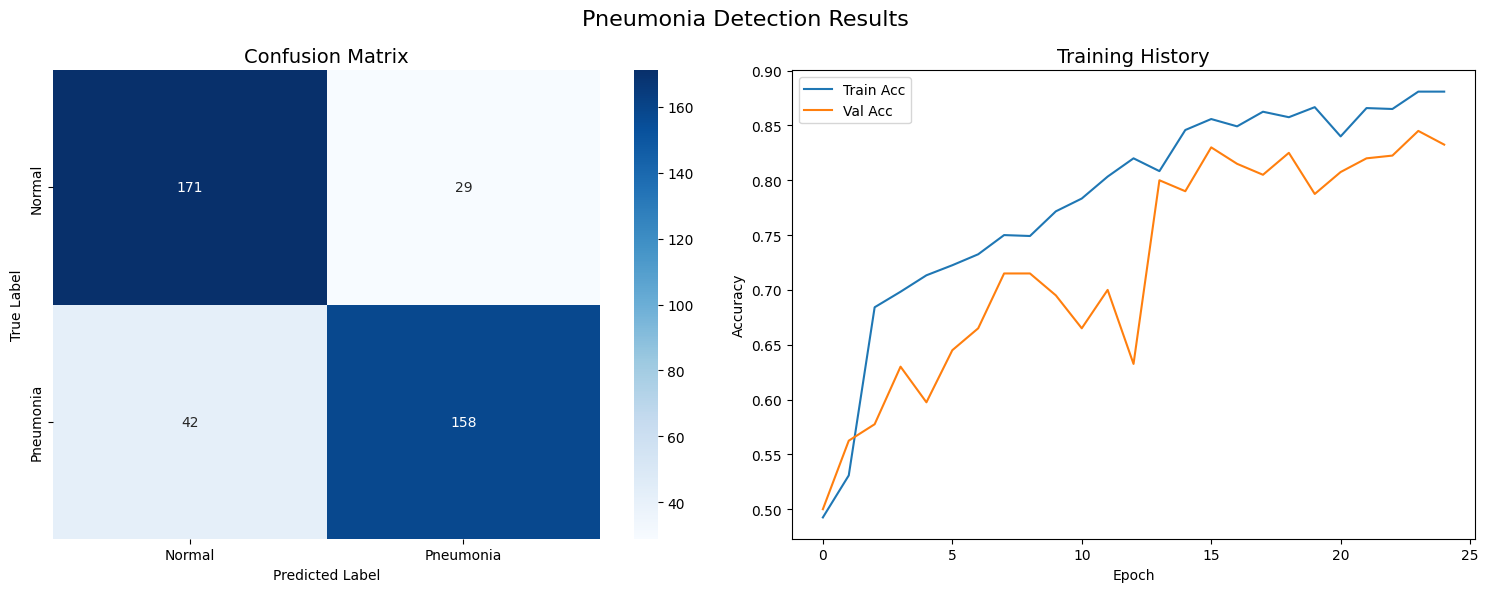

Results saved! ✅


In [17]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred,
    target_names=['Normal', 'Pneumonia']))

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(cm, annot=True, fmt='d', ax=axes[0],
    cmap='Blues',
    xticklabels=['Normal', 'Pneumonia'],
    yticklabels=['Normal', 'Pneumonia'])
axes[0].set_title('Confusion Matrix', fontsize=14)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

axes[1].plot(history.history['accuracy'], label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Training History', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Pneumonia Detection Results', fontsize=16)
plt.tight_layout()
plt.savefig('pneumonia_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Results saved! ✅")

In [18]:
import pickle

# Save full model
model.save('pneumonia_model.h5')
print("✅ Model saved as H5")

# Convert to TFLite for deployment
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('pneumonia_model.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"✅ TFLite model size: {len(tflite_model)/1024/1024:.2f} MB")

✅ Model saved as H5
Saved artifact at '/tmp/tmpouim1orn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132390824488464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132390824484624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132390824489040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132390824484816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132390824490000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132390824489424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132390824490192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132390824489616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132390824488080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132390824490576: TensorSpec(shape=(), dtype=tf.resource, name=No

In [19]:
from google.colab import files

files.download('pneumonia_samples.png')
files.download('pneumonia_results.png')
files.download('pneumonia_model.tflite')
print("All downloaded! ✅")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All downloaded! ✅


In [20]:
from google.colab import files


files.download('pneumonia_results.png')
files.download('pneumonia_model.tflite')
print("All downloaded! ✅")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All downloaded! ✅
